<a href="https://colab.research.google.com/github/s32230055-sketch/MachineLearningUAS/blob/main/Machine_learning_comparison_modified.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix

In [4]:
df = pd.read_excel("DBDS.xlsx")

In [5]:
print("Jumlah Baris dan Kolom:")
print(df.shape)


print("\n5 Data Pertama\t:")
display(df.head())

print("\n Setelah di round\t: ")
display(df.head().round(2))
print("\nInformasi Dataset:")
df.info()


Jumlah Baris dan Kolom:
(13611, 17)

5 Data Pertama	:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



 Setelah di round	: 


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.29,208.18,173.89,1.20,0.55,28715,190.14,0.76,0.99,0.96,0.91,0.01,0.0,0.83,1.00,SEKER
1,28734,638.02,200.52,182.73,1.10,0.41,29172,191.27,0.78,0.98,0.89,0.95,0.01,0.0,0.91,1.00,SEKER
2,29380,624.11,212.83,175.93,1.21,0.56,29690,193.41,0.78,0.99,0.95,0.91,0.01,0.0,0.83,1.00,SEKER
3,30008,645.88,210.56,182.52,1.15,0.50,30724,195.47,0.78,0.98,0.90,0.93,0.01,0.0,0.86,0.99,SEKER
4,30140,620.13,201.85,190.28,1.06,0.33,30417,195.90,0.77,0.99,0.98,0.97,0.01,0.0,0.94,1.00,SEKER



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  objec

In [6]:
print("Jumlah Missing Value per Kolom:")
print(df.isnull().sum())

Jumlah Missing Value per Kolom:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [7]:
duplicates = df.duplicated().sum()

print("Jumlah Data Duplikat:")
print(duplicates)

Jumlah Data Duplikat:
68


In [8]:
display(df.describe().round(2))

print("round\t: ")
df.describe().round(2)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.0,13611.00,13611.00
mean,53048.28,855.28,320.14,202.27,1.58,0.75,53768.20,253.06,0.75,0.99,0.87,0.80,0.01,0.0,0.64,1.00
std,29324.10,214.29,85.69,44.97,0.25,0.09,29774.92,59.18,0.05,0.00,0.06,0.06,0.00,0.0,0.10,0.00
min,20420.00,524.74,183.60,122.51,1.02,0.22,20684.00,161.24,0.56,0.92,0.49,0.64,0.00,0.0,0.41,0.95
25%,36328.00,703.52,253.30,175.85,1.43,0.72,36714.50,215.07,0.72,0.99,0.83,0.76,0.01,0.0,0.58,0.99
50%,44652.00,794.94,296.88,192.43,1.55,0.76,45178.00,238.44,0.76,0.99,0.88,0.80,0.01,0.0,0.64,1.00
75%,61332.00,977.21,376.50,217.03,1.71,0.81,62294.00,279.45,0.79,0.99,0.92,0.83,0.01,0.0,0.70,1.00
max,254616.00,1985.37,738.86,460.20,2.43,0.91,263261.00,569.37,0.87,0.99,0.99,0.99,0.01,0.0,0.97,1.00


round	: 


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.0,13611.00,13611.00
mean,53048.28,855.28,320.14,202.27,1.58,0.75,53768.20,253.06,0.75,0.99,0.87,0.80,0.01,0.0,0.64,1.00
std,29324.10,214.29,85.69,44.97,0.25,0.09,29774.92,59.18,0.05,0.00,0.06,0.06,0.00,0.0,0.10,0.00
min,20420.00,524.74,183.60,122.51,1.02,0.22,20684.00,161.24,0.56,0.92,0.49,0.64,0.00,0.0,0.41,0.95
25%,36328.00,703.52,253.30,175.85,1.43,0.72,36714.50,215.07,0.72,0.99,0.83,0.76,0.01,0.0,0.58,0.99
50%,44652.00,794.94,296.88,192.43,1.55,0.76,45178.00,238.44,0.76,0.99,0.88,0.80,0.01,0.0,0.64,1.00
75%,61332.00,977.21,376.50,217.03,1.71,0.81,62294.00,279.45,0.79,0.99,0.92,0.83,0.01,0.0,0.70,1.00
max,254616.00,1985.37,738.86,460.20,2.43,0.91,263261.00,569.37,0.87,0.99,0.99,0.99,0.01,0.0,0.97,1.00


In [9]:
class_proportion = df["Class"].value_counts()
class_proportion_percentage = df["Class"].value_counts(normalize=True) * 100
print(class_proportion)
print("\nDalam bentuk Persentase\t: ")
print(class_proportion_percentage)

print("\n\n Setelah di round\t: ")
print(class_proportion.round(2))
print("\nDalam bentuk Persentase\t: ")
print(class_proportion_percentage.round(2))

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Dalam bentuk Persentase	: 
Class
DERMASON    26.052458
SIRA        19.366689
SEKER       14.892366
HOROZ       14.165014
CALI        11.975608
BARBUNYA     9.712732
BOMBAY       3.835133
Name: proportion, dtype: float64


 Setelah di round	: 
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Dalam bentuk Persentase	: 
Class
DERMASON    26.05
SIRA        19.37
SEKER       14.89
HOROZ       14.17
CALI        11.98
BARBUNYA     9.71
BOMBAY       3.84
Name: proportion, dtype: float64


In [10]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [11]:
print(y.unique())
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)
mapping = dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
))

print(mapping)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)
display(X_scaled.head())
print("\n\nSetelah di round\t: ")

display(X_scaled.head().round(2))

['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']
{'BARBUNYA': np.int64(0), 'BOMBAY': np.int64(1), 'CALI': np.int64(2), 'DERMASON': np.int64(3), 'HOROZ': np.int64(4), 'SEKER': np.int64(5), 'SIRA': np.int64(6)}


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,-0.840749,-1.143319,-1.306598,-0.631153,-1.565053,-2.185720,-0.841451,-1.063341,0.289087,0.367613,1.423867,1.839116,0.680786,2.402173,1.925723,0.838371
1,-0.829188,-1.013924,-1.395911,-0.434445,-1.969784,-3.686040,-0.826102,-1.044217,0.697477,-0.462907,0.231054,2.495449,0.367967,3.100893,2.689702,0.771138
2,-0.807157,-1.078829,-1.252357,-0.585735,-1.514291,-2.045336,-0.808704,-1.008084,0.578195,0.518417,1.252865,1.764843,0.603129,2.235091,1.841356,0.916755
3,-0.785741,-0.977215,-1.278825,-0.439290,-1.741618,-2.742211,-0.773975,-0.973337,0.671260,-2.241767,0.515049,2.081715,0.401718,2.515075,2.204250,-0.197985
4,-0.781239,-1.097384,-1.380471,-0.266663,-2.117993,-4.535028,-0.784286,-0.966080,0.476020,0.804772,1.874992,2.765330,0.118268,3.270983,3.013462,0.939640




Setelah di round	: 


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,-0.84,-1.14,-1.31,-0.63,-1.57,-2.19,-0.84,-1.06,0.29,0.37,1.42,1.84,0.68,2.40,1.93,0.84
1,-0.83,-1.01,-1.40,-0.43,-1.97,-3.69,-0.83,-1.04,0.70,-0.46,0.23,2.50,0.37,3.10,2.69,0.77
2,-0.81,-1.08,-1.25,-0.59,-1.51,-2.05,-0.81,-1.01,0.58,0.52,1.25,1.76,0.60,2.24,1.84,0.92
3,-0.79,-0.98,-1.28,-0.44,-1.74,-2.74,-0.77,-0.97,0.67,-2.24,0.52,2.08,0.40,2.52,2.20,-0.20
4,-0.78,-1.10,-1.38,-0.27,-2.12,-4.54,-0.78,-0.97,0.48,0.80,1.87,2.77,0.12,3.27,3.01,0.94


In [12]:
print("Nilai rata-rata\t: ")
print(X_scaled.mean(),"\n\n")

print("Standar deviasi\t: ")
print(X_scaled.std())

print("\n\n\n\nSetelah di round\t: ")
print(X_scaled.mean().round(2),"\n\n")

print("Standar deviasi\t: ")
print(X_scaled.std().round(2))

Nilai rata-rata	: 
Area               3.341028e-17
Perimeter         -1.002308e-16
MajorAxisLength   -1.336411e-16
MinorAxisLength    3.675131e-16
AspectRation      -4.343337e-16
Eccentricity      -2.276075e-16
ConvexArea         1.002308e-16
EquivDiameter     -1.336411e-16
Extent            -1.992088e-15
Solidity          -2.298627e-14
roundness          3.341028e-17
Compactness       -1.670514e-17
ShapeFactor1      -1.670514e-16
ShapeFactor2       1.336411e-16
ShapeFactor3       7.517313e-17
ShapeFactor4       1.966195e-14
dtype: float64 


Standar deviasi	: 
Area               1.000037
Perimeter          1.000037
MajorAxisLength    1.000037
MinorAxisLength    1.000037
AspectRation       1.000037
Eccentricity       1.000037
ConvexArea         1.000037
EquivDiameter      1.000037
Extent             1.000037
Solidity           1.000037
roundness          1.000037
Compactness        1.000037
ShapeFactor1       1.000037
ShapeFactor2       1.000037
ShapeFactor3       1.000037
ShapeFactor4

In [13]:
print("Jumlah Sampel :", df.shape[0])
print("Jumlah Fitur  :", X.shape[1])
print("Jumlah Kelas  :", len(np.unique(y)))

print("\nTotal Missing Value :", df.isnull().sum().sum())
print("Total Duplikat      :", duplicates)

Jumlah Sampel : 13611
Jumlah Fitur  : 16
Jumlah Kelas  : 7

Total Missing Value : 0
Total Duplikat      : 68


Metode Elbow	:
1 217775.99999999907
2 129900.03393116494
3 94741.98656531739
4 76474.30922656799
5 61893.644351996954
6 55050.06962030738
7 48811.95642626721
8 45241.726459331774
9 41975.59482530584
10 39810.685041307865


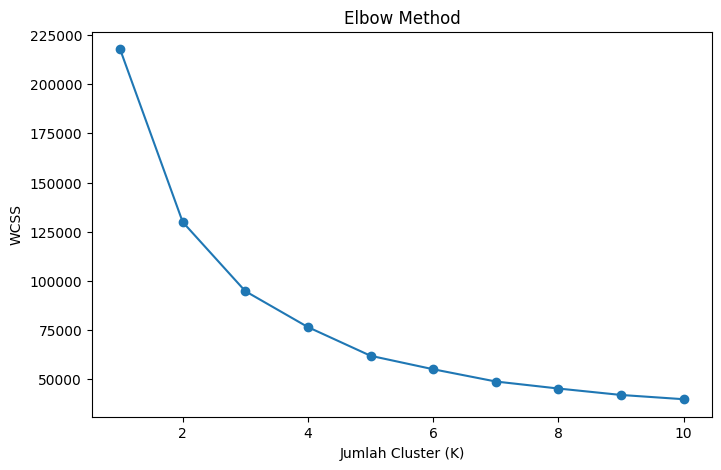

In [14]:
print("Metode Elbow\t:")

wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)
    print(k, wcss[-1])


plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

Metode silhouette score	: 
Cluster	:  2 
Score	: 0.39665358971827025
Cluster	:  3 
Score	: 0.4047452116044009
Cluster	:  4 
Score	: 0.341642682168923
Cluster	:  5 
Score	: 0.3568984864249916
Cluster	:  6 
Score	: 0.36017307467548715
Cluster	:  7 
Score	: 0.30937979043741126
Cluster	:  8 
Score	: 0.3030787910610453
Cluster	:  9 
Score	: 0.30329847161083956
Cluster	:  10 
Score	: 0.266054645088465


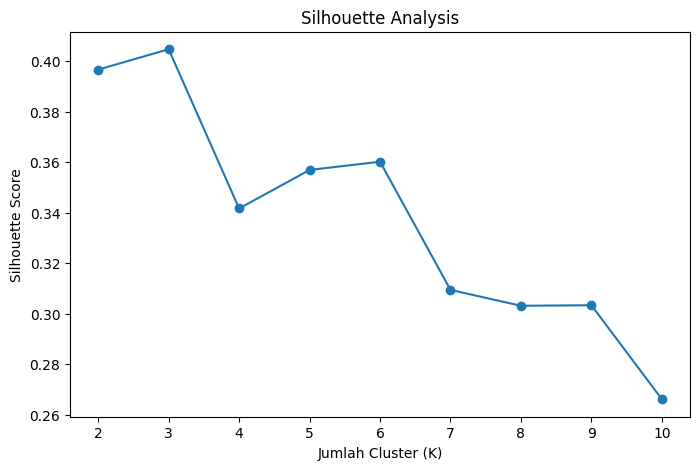

In [15]:
print("Metode silhouette score\t: ")
scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)
    print("Cluster\t: ",k, "\nScore\t:", score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()


In [16]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [17]:
df["Cluster"] = clusters

In [18]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

display(cluster_profile)
display(cluster_profile.round(2))

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
Cluster,,,,,,,,,,,,,,,,
0,37416.245943,714.537122,260.004380,182.590215,1.432422,0.699427,37834.843779,217.273627,0.759136,0.988872,0.913846,0.837646,0.007083,0.002160,0.703611,0.997085
1,173264.839695,1584.640353,592.700642,374.122583,1.585303,0.770403,175591.919847,468.617069,0.776500,0.986885,0.864270,0.792691,0.003445,0.000845,0.629310,0.991839
2,63121.223130,979.563320,376.961261,213.002036,1.790574,0.819859,64102.855120,281.805543,0.734248,0.984788,0.818323,0.748558,0.006146,0.001188,0.562360,0.992588


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
Cluster,,,,,,,,,,,,,,,,
0,37416.25,714.54,260.00,182.59,1.43,0.70,37834.84,217.27,0.76,0.99,0.91,0.84,0.01,0.0,0.70,1.00
1,173264.84,1584.64,592.70,374.12,1.59,0.77,175591.92,468.62,0.78,0.99,0.86,0.79,0.00,0.0,0.63,0.99
2,63121.22,979.56,376.96,213.00,1.79,0.82,64102.86,281.81,0.73,0.98,0.82,0.75,0.01,0.0,0.56,0.99


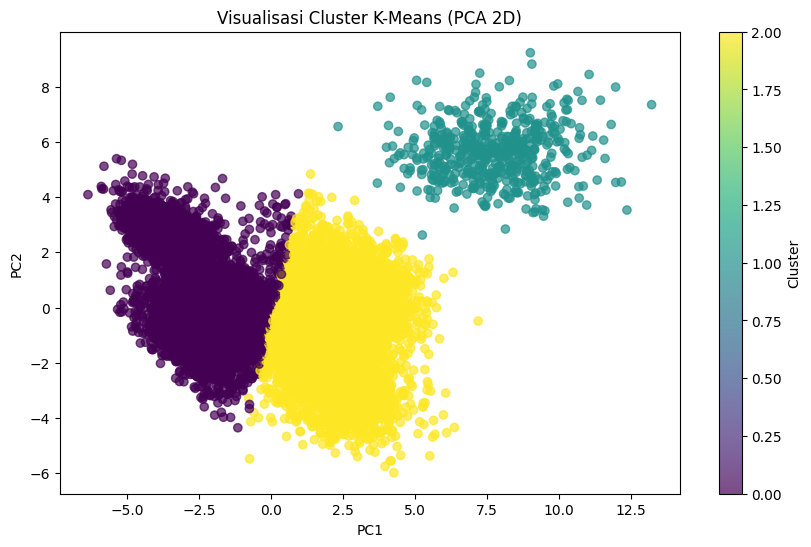

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


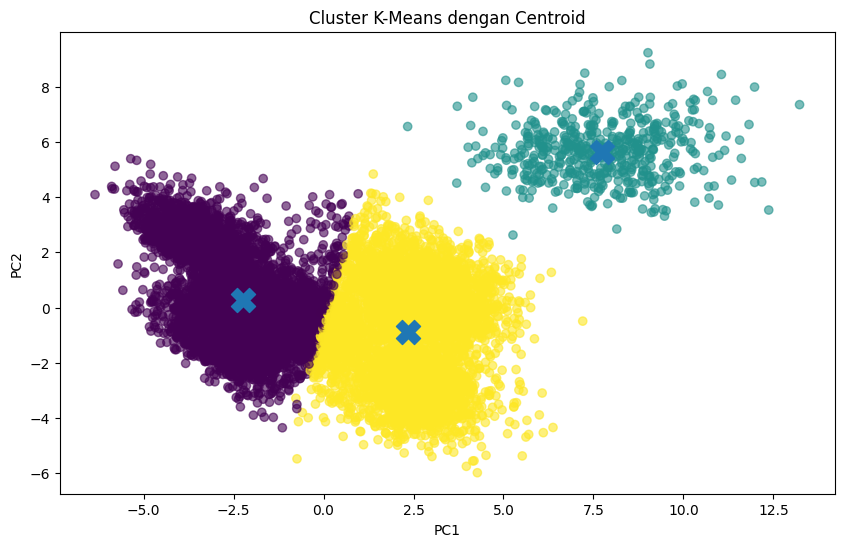

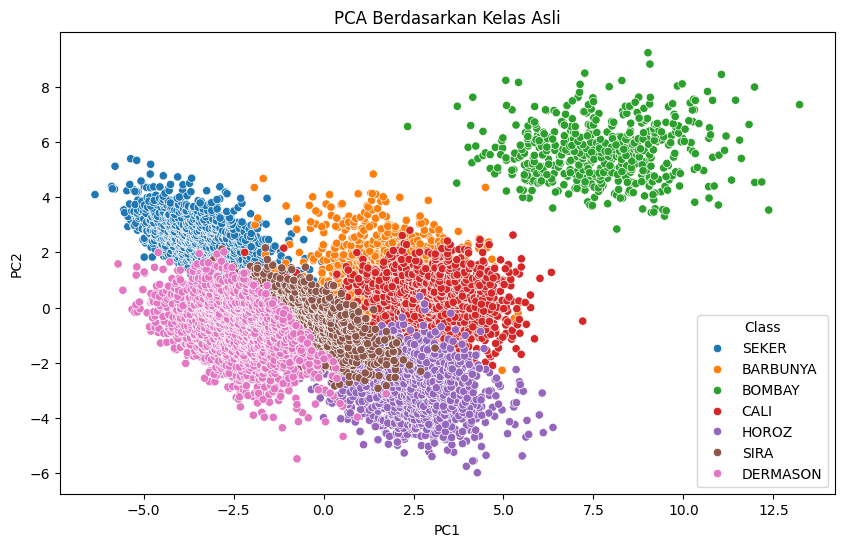

In [19]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

plt.figure(figsize=(10,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualisasi Cluster K-Means (PCA 2D)")

plt.colorbar(label="Cluster")

plt.show()

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    alpha=0.6
)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    s=300,
    marker="X"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cluster K-Means dengan Centroid")

plt.show()

pca_df["Class"] = y
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Class",
    palette="tab10"
)

plt.title("PCA Berdasarkan Kelas Asli")

plt.show()

In [20]:
pd.crosstab(
    df["Cluster"],
    df["Class"]
)

Class,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
Cluster,,,,,,,
0,108,0,7,3507,19,2019,1919
1,1,522,1,0,0,0,0
2,1213,0,1622,39,1909,8,717


In [21]:

cluster_profile = (
    df.groupby('Cluster')
      .mean(numeric_only=True)
      .reset_index()
)
display(cluster_profile)
display(cluster_profile.round(2))

,Cluster,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,0,37416.245943,714.537122,260.004380,182.590215,1.432422,0.699427,37834.843779,217.273627,0.759136,0.988872,0.913846,0.837646,0.007083,0.002160,0.703611,0.997085
1,1,173264.839695,1584.640353,592.700642,374.122583,1.585303,0.770403,175591.919847,468.617069,0.776500,0.986885,0.864270,0.792691,0.003445,0.000845,0.629310,0.991839
2,2,63121.223130,979.563320,376.961261,213.002036,1.790574,0.819859,64102.855120,281.805543,0.734248,0.984788,0.818323,0.748558,0.006146,0.001188,0.562360,0.992588


,Cluster,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,0,37416.25,714.54,260.00,182.59,1.43,0.70,37834.84,217.27,0.76,0.99,0.91,0.84,0.01,0.0,0.70,1.00
1,1,173264.84,1584.64,592.70,374.12,1.59,0.77,175591.92,468.62,0.78,0.99,0.86,0.79,0.00,0.0,0.63,0.99
2,2,63121.22,979.56,376.96,213.00,1.79,0.82,64102.86,281.81,0.73,0.98,0.82,0.75,0.01,0.0,0.56,0.99


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [23]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

lda_acc = accuracy_score(
    y_test,
    y_pred_lda
)

print("LDA Accuracy:", lda_acc)
print(f"LDA Accuracy : {lda_acc*100:.2f}%")

LDA Accuracy: 0.9045170767535806
LDA Accuracy : 90.45%


In [24]:
ann = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=100,
    random_state=42, early_stopping=True
)

ann.fit(X_train, y_train)

y_pred_ann = ann.predict(X_test)


ann_acc = accuracy_score(
    y_test,
    y_pred_ann
)

print("ANN Accuracy:", ann_acc)
print(f"ANN Accuracy : {ann_acc*100:.2f}%")

ANN Accuracy: 0.9254498714652957
ANN Accuracy : 92.54%


In [25]:
comparison = pd.DataFrame({
    "Model":["LDA","ANN"],
    "Accuracy":[lda_acc, ann_acc],
    "%ACC": [f"{lda_acc*100:.2f}%", f"{ann_acc*100:.2f}%"]
})
comparison

,Model,Accuracy,%ACC
0,LDA,0.904517,90.45%
1,ANN,0.925450,92.54%


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error as mse_score
)

lda_acc = accuracy_score(y_test, y_pred_lda)
lda_prec = precision_score(y_test, y_pred_lda, average='weighted')
lda_rec = recall_score(y_test, y_pred_lda, average='weighted')
lda_f1 = f1_score(y_test, y_pred_lda, average='weighted')
lda_mse = mse_score(y_test, y_pred_lda)

ann_acc = accuracy_score(y_test, y_pred_ann)
ann_prec = precision_score(y_test, y_pred_ann, average='weighted')
ann_rec = recall_score(y_test, y_pred_ann, average='weighted')
ann_f1 = f1_score(y_test, y_pred_ann, average='weighted')
ann_mse = mse_score(y_test, y_pred_ann)

comparison = pd.DataFrame({
    "Model": ["LDA", "ANN"],
    "Accuracy": [lda_acc, ann_acc],
    "Precision": [lda_prec, ann_prec],
    "Recall": [lda_rec, ann_rec],
    "F1-Score": [lda_f1, ann_f1],
    "MSE-Score": [lda_mse, ann_mse]
})

comparison = comparison.round(4)

print("Perbandingan Performa Model:")
display(comparison)

Perbandingan Performa Model:


,Model,Accuracy,Precision,Recall,F1-Score,MSE-Score
0,LDA,0.9045,0.9145,0.9045,0.9059,0.8667
1,ANN,0.9254,0.9257,0.9254,0.9255,0.6023


In [27]:
from sklearn.metrics import classification_report

print("Class Mapping:")
for i, label in enumerate(encoder.classes_):
    print(f"{i} = {label}")

print("\n=== LDA ===")
print(classification_report(y_test, y_pred_lda))

print("\n=== ANN ===")
print(classification_report(y_test, y_pred_ann))

Class Mapping:
0 = BARBUNYA
1 = BOMBAY
2 = CALI
3 = DERMASON
4 = HOROZ
5 = SEKER
6 = SIRA

=== LDA ===
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       265
           1       1.00      1.00      1.00       104
           2       0.89      0.96      0.92       326
           3       0.95      0.85      0.90       709
           4       0.97      0.92      0.94       386
           5       0.95      0.93      0.94       406
           6       0.76      0.94      0.84       527

    accuracy                           0.90      2723
   macro avg       0.93      0.92      0.92      2723
weighted avg       0.91      0.90      0.91      2723


=== ANN ===
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       265
           1       1.00      1.00      1.00       104
           2       0.94      0.93      0.93       326
           3       0.93      0.92      0.92       709
           4    

In [28]:
print("Confusion matrix untuk LDA\t:")
cm_lda = confusion_matrix(
    y_test,
    y_pred_lda
)

print(cm_lda)

print("\n\nConfusion matrix untuk ANN\t:")
cm_ann = confusion_matrix(
    y_test,
    y_pred_ann
)

print(cm_ann)

Confusion matrix untuk LDA	:
[[216   0  26   0   1   3  19]
 [  0 104   0   0   0   0   0]
 [  2   0 312   0   4   2   6]
 [  0   0   0 604   0  10  95]
 [  1   0  12   4 355   0  14]
 [  1   0   0   6   0 376  23]
 [  1   0   0  21   6   3 496]]


Confusion matrix untuk ANN	:
[[240   0  16   0   0   4   5]
 [  0 104   0   0   0   0   0]
 [ 14   0 302   0   5   2   3]
 [  0   0   0 649   0  13  47]
 [  2   0   2   5 370   0   7]
 [  2   0   0   5   0 389  10]
 [  3   0   0  42   8   8 466]]


In [29]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y_encoded, clusters)
nmi = normalized_mutual_info_score(y_encoded, clusters)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.2985
Normalized Mutual Information (NMI): 0.4862
